# LLM Fine-Tuning with Transformers

Full fine-tuning of **Qwen/Qwen2.5-0.5B-Instruct** on a multiple-choice question dataset using Hugging Face Transformers and TRL.

Training data: MMLU `machine_learning` subset. Eval data: held-out MCQ CSV. Accuracy measured before and after training to quantify improvement.

## Setup

In [41]:
import sys
IS_COLAB = 'google.colab' in sys.modules
if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    %pip install -q transformers==4.57.2 accelerate datasets trl bitsandbytes

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/hw5cs189


In [42]:
import os
import re
import math
import pandas as pd
import torch
from datasets import Dataset, concatenate_datasets, load_dataset, load_from_disk
from trl import SFTTrainer, SFTConfig
from transformers import AutoModelForCausalLM, AutoTokenizer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#MAKE SURE YOU ARE USING GPU
print('Using device:', device)

Using device: cuda


## Configuration & Model Loading

Loading `Qwen/Qwen2.5-0.5B-Instruct` and its tokenizer. Setting training hyperparameters in one place.

In [43]:
# ============================================================================
# === CONFIGURATION - ALL SETTINGS IN ONE PLACE ===
# ============================================================================

# --- Model Configuration ---
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct" 

# --- Dataset Configuration ---
MCQ_CSV_PATH = "hw5_sample_eval.csv"  # Path to MCQ evaluation dataset CSV

# --- Training Configuration (feel free to adjust!) ---
TRAIN_BATCH_SIZE = 3
GRADIENT_ACCUMULATION_STEPS = 4
WARMUP_STEPS = 5
MAX_STEPS = 170  # or set num_train_epochs instead
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
LR_SCHEDULER_TYPE = "cosine"
OPTIM = "adamw_8bit"  # requires bitsandbytes
SEED = 189

# --- Evaluation Configuration ---
EVAL_MAX_NEW_TOKENS = 64  # How many tokens to generate for inference
OUTPUT_DIR = "./mcq_finetuned_model"

In [44]:
# === Load base model & tokenizer ===
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Ensure we have a pad token for training
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
)
model.resize_token_embeddings(len(tokenizer))
model.to(device)
model.eval()
print('Model loaded.')

Model loaded.


## Data Preparation

Loading the MCQ CSV and MMLU training set. Each row is formatted into a chat-style training example with the question as the user turn and `\boxed{answer}` as the assistant turn.

In [45]:
# === MCQ helpers ===
LETTER_SET = set(list("ABCDE"))

def load_mcq_dataset(csv_path: str = MCQ_CSV_PATH):
    """Load the MCQ dataset.

    Expected columns:
        - question
        - A, B, C, D, E
        - answer (single letter A-E)
    """
    df = pd.read_csv(csv_path)
    required = ["question", "A", "B", "C", "D", "E", "answer"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in MCQ CSV: {missing}")

    df = df.copy()
    df["answer"] = (
        df["answer"]
        .astype(str)
        .str.strip()
        .str.upper()
    )
    df = df[df["answer"].isin(LETTER_SET)].reset_index(drop=True)
    return df

def build_mcq_prompt(row):
    """Prompt for inference: instruction + question + options.

    The model is expected to answer with the correct letter in \\boxed{} format.
    """
    q = str(row["question"]).strip()
    options = "\n".join([
        f"A. {row['A']}",
        f"B. {row['B']}",
        f"C. {row['C']}",
        f"D. {row['D']}",
        f"E. {row['E']}",
    ])
    prompt = (
        "Choose exactly one correct option from A, B, C, D, and E.\n"
        "Return your answer inside a LaTeX box.\n\n"
        f"{q}\n\n{options}\n\nAnswer:"
    )
    return prompt

Each training example uses the chat template with `<|im_start|>`/`<|im_end|>` tokens to delimit user and assistant turns.

In [46]:
def parse_choice_from_boxed(text: str):
    """Parse an MCQ choice A–E from the model output.

    We first look for a literal '\\boxed{X}' pattern. If not found, we
    fallback to the last standalone A-E in the decoded text.
    """
    if text is None:
        return None
    # Direct \\boxed{A} ... \\boxed{E}
    m = re.search(r"\\boxed\{\s*([A-E])\s*\}", text)
    if m:
        return m.group(1)
    # Fallback: last standalone A–E
    letters = re.findall(r"\b([A-E])\b", text.upper())
    if letters:
        return letters[-1]
    return None

Loading and formatting the MCQ evaluation CSV.

In [47]:
# === Load MCQ CSV (Evaluation Data) ===
MCQ_CSV_PATH = 'hw5_sample_eval.csv'  # update path as needed
try:
    mcq_df = load_mcq_dataset(MCQ_CSV_PATH)
    print(f"Loaded MCQ dataset with {len(mcq_df)} rows from {MCQ_CSV_PATH}.")
except Exception as e:
    mcq_df = None
    print("Error loading MCQ CSV — check MCQ_CSV_PATH.")
    raise e
mcq_df

Loaded MCQ dataset with 25 rows from /content/drive/MyDrive/hw5cs189/hw5_sample_eval.csv.


,id,question,A,B,C,D,E,answer
0,mcq_1,Peanut wants to train a model to accurately cl...,High bias.,Low bias.,High variance.,Low variance.,none of the above,A
1,mcq_2,Consider a binary classification data set with...,Close to zero.,Close to 0.1.,Close to 0.5.,Close to 0.9.,Close to one.,C
2,mcq_3,"Again, consider a binary classification data s...","The precision is 0.1, and the recall is 0.9.","The precision is 0.9, and the recall is 0.1.","The precision is 1.0, and the recall is 0.9.","The precision is 0.9, and the recall is 1.0.","The precision is 0.1, and the recall is 1.0.",D
3,mcq_4,Assume we are given X ∈ Rn×d and y ∈ Rn for n ...,"y′ = [ y; 0d ], X′ = [ X; √λ Id ]","y′ = [ y; 1d ], X′ = [ X; √λ Id ]","y′ = [ y; 0d ], X′ = [ X; λ Id ]","y′ = [ y; 1d ], X′ = [ X; λ Id ]",none of the above,A
4,mcq_5,Which of the following statements are TRUE reg...,“Every entry of a matrix is non-negative” is a...,The singular values of a positive semi-definit...,"If a matrix A is positive semi-definite, then ...",The covariance matrix of any distribution is p...,If the Jacobian of a function is positive semi...,B
5,mcq_6,Which of the following statements are TRUE reg...,"In the Bayesian MAP interpretation, Lasso regr...","In Lasso regression, as the regularization coe...",Lasso regression performs both feature expansi...,There is no unique solution to Ridge regressio...,none of the above,B
6,mcq_7,If the model resulting from Ridge regression i...,Collect new data to increase the training data...,Repeat the current data twice to increase the ...,Increase the ℓ1 regularization penalty in the ...,Add new features to the model.,Add synthetic features from the model.,A
7,mcq_8,Which of the following statements are TRUE abo...,"After a gradient descent update step, the obje...",There is always a unique steepest descent dire...,Gradient descent converges to a globally optim...,"Since ReLU is a convex function, a neural netw...",none of the above,C
8,mcq_9,Which of the following statements are TRUE abo...,The value of cross-entropy loss is always non-...,Cross-entropy loss is only suitable for binary...,For two discrete probability distributions P a...,Minimizing the cross-entropy is equivalent to ...,none of the above,A
9,mcq_10,Which of the following statements are TRUE abo...,"During the k-fold cross validation process, pr...","During the k-fold cross validation process, pr...","During the k-fold cross validation process, we...",At the end of the k-fold cross validation proc...,none of the above,A


Loading the MMLU `machine_learning` subset from Hugging Face as training data.

In [48]:
# === MMLU Helper Functions ===
def load_mmlu_dataset(subset: str = "machine_learning", split: str = "test"):
    """Load a subset of the MMLU dataset from Hugging Face."""
    print(f"Loading MMLU dataset (subset={subset}, split={split})...")
    ds = load_dataset("cais/mmlu", subset, split=split)
    return ds

def build_mmlu_prompt(row):
    """Prompt for inference: instruction + question + options."""
    q = str(row["question"]).strip()
    choices = row["choices"]

    options_list = []
    for i, choice in enumerate(choices):
        letter = chr(ord("A") + i)
        options_list.append(f"{letter}. {choice}")
    options_str = "\n".join(options_list)

    prompt = (
        "Choose exactly one correct option from the choices provided.\n"
        "Return your answer inside a LaTeX box.\n\n"
        f"{q}\n\n{options_str}\n\nAnswer:"
    )
    return prompt

def build_mmlu_sft_text(row, tokenizer):
    """Build properly formatted chat template text for training."""
    user_content = build_mmlu_prompt(row)

    answer_int = row["answer"]
    answer_letter = chr(ord("A") + answer_int)
    assistant_content = f"\\boxed{{{answer_letter}}}"

    messages = [
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": assistant_content}
    ]

    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False
    )

def build_mcq_csv_sft_text(row, tokenizer):
    """ for choices a-e """
    user_content = build_mcq_prompt(row)
    assistant_content = f"\\boxed{{{row['answer']}}}"
    messages = [
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": assistant_content},
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False
    )

# === Load MMLU Machine Learning Dataset ===
mmlu_subsets = [
    'machine_learning','high_school_statistics','high_school_mathematics','high_school_computer_science',
    'formal_logic','college_computer_science', 'college_mathematics','logical_fallacies','miscellaneous'
    ]

mmlu_datasets = []
mmlu_datasets = [load_mmlu_dataset(s, split="test") for s in mmlu_subsets]

mmlu_ds = concatenate_datasets(mmlu_datasets)
mmlu_text_ds = mmlu_ds.map(lambda x: {"text": build_mmlu_sft_text(x, tokenizer)})

# mmlu_ds = load_mmlu_dataset("machine_learning", split="test")
# mmlu_text_ds = mmlu_ds.map(lambda x: {"text": build_mmlu_sft_text(x, tokenizer)})
print("Loaded MMLU ML dataset with", len(mmlu_text_ds), "rows")

mcq_texts = [build_mcq_csv_sft_text(mcq_df.iloc[i], tokenizer)
               for i in range(len(mcq_df))]
mcq_text_ds = Dataset.from_dict({"text": mcq_texts})
mcq_repeated = concatenate_datasets([mcq_text_ds] * 10) # balance data set since not predicting E


# Set the training dataset - you can mix and match datasets here
# train_dataset = mmlu_text_ds

train_dataset = concatenate_datasets([
    mmlu_text_ds.select_columns(["text"]),
    mcq_repeated.select_columns(["text"]),
])

Loading MMLU dataset (subset=machine_learning, split=test)...
Loading MMLU dataset (subset=high_school_statistics, split=test)...
Loading MMLU dataset (subset=high_school_mathematics, split=test)...
Loading MMLU dataset (subset=high_school_computer_science, split=test)...
Loading MMLU dataset (subset=formal_logic, split=test)...
Loading MMLU dataset (subset=college_computer_science, split=test)...
Loading MMLU dataset (subset=college_mathematics, split=test)...
Loading MMLU dataset (subset=logical_fallacies, split=test)...


logical_fallacies/test-00000-of-00001.pa(…):   0%|          | 0.00/23.0k [00:00<?, ?B/s]

logical_fallacies/validation-00000-of-00(…):   0%|          | 0.00/6.52k [00:00<?, ?B/s]

logical_fallacies/dev-00000-of-00001.par(…):   0%|          | 0.00/4.12k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/163 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/18 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/5 [00:00<?, ? examples/s]

Loading MMLU dataset (subset=miscellaneous, split=test)...


Map:   0%|          | 0/1970 [00:00<?, ? examples/s]

Loaded MMLU ML dataset with 1970 rows


Sample formatted training example showing what the model sees as input:

In [49]:
# print out what the first row looks like
print(train_dataset[0]['text'])

<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
Choose exactly one correct option from the choices provided.
Return your answer inside a LaTeX box.

Statement 1| Linear regression estimator has the smallest variance among all unbiased estimators. Statement 2| The coefficients α assigned to the classifiers assembled by AdaBoost are always non-negative.

A. True, True
B. False, False
C. True, False
D. False, True

Answer:<|im_end|>
<|im_start|>assistant
\boxed{D}<|im_end|>



## Baseline Evaluation

Running the base model on the MCQ set before fine-tuning to establish a zero-shot accuracy baseline.

In [50]:
def eval_mcq_accuracy(
    curr_model,
    curr_tokenizer,
    df,
    max_new_tokens: int = 64,
    return_details: bool = False,
):
    """Evaluate a model on the MCQ dataset using greedy decoding.

    If return_details=True, also return a pandas DataFrame with
    [idx, question, A, B, C, D, E, gold, decoded, parsed, correct].
    """
    curr_model.eval()
    n = len(df)
    correct = 0
    total = 0
    records = []

    for idx in range(n):
        row = df.iloc[idx]
        user_content = build_mcq_prompt(row)

        # Apply chat template for inference
        messages = [{"role": "user", "content": user_content}]
        prompt = curr_tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )

        inputs = curr_tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = curr_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
            )

        gen_tokens = outputs[0][inputs["input_ids"].shape[1]:]
        decoded = curr_tokenizer.decode(gen_tokens, skip_special_tokens=True)

        pred = parse_choice_from_boxed(decoded)
        is_correct = (pred is not None and pred == row["answer"])
        if is_correct:
            correct += 1
        total += 1

        records.append({
            "idx": idx,
            "question": row["question"],
            "A": row["A"],
            "B": row["B"],
            "C": row["C"],
            "D": row["D"],
            "E": row["E"],
            "gold": row["answer"],
            "prompt": prompt,
            "decoded": decoded,
            "parsed": pred,
            "correct": is_correct,
        })

        if (idx + 1) % 20 == 0:
            print(f"Processed {idx + 1}/{n} questions...")

    acc = correct / max(total, 1)
    print(f"MCQ accuracy: {acc * 100:.2f}% ({correct}/{total})")

    details_df = pd.DataFrame(records)
    if return_details:
        return acc, details_df
    return acc

# === Baseline MCQ accuracy before fine-tuning ===
print("Evaluating baseline model on MCQ dataset...")
baseline_acc, baseline_details = eval_mcq_accuracy(
    model,
    tokenizer,
    mcq_df,
    max_new_tokens=EVAL_MAX_NEW_TOKENS,
    return_details=True,
)
baseline_details.head()

Evaluating baseline model on MCQ dataset...
Processed 20/25 questions...
MCQ accuracy: 24.00% (6/25)


,idx,question,A,B,C,D,E,gold,prompt,decoded,parsed,correct
0,0,Peanut wants to train a model to accurately cl...,High bias.,Low bias.,High variance.,Low variance.,none of the above,A,"<|im_start|>system\nYou are Qwen, created by A...",To determine what we can most confidently say ...,A,True
1,1,Consider a binary classification data set with...,Close to zero.,Close to 0.1.,Close to 0.5.,Close to 0.9.,Close to one.,C,"<|im_start|>system\nYou are Qwen, created by A...",To determine the area under the ROC curve (AUC...,A,False
2,2,"Again, consider a binary classification data s...","The precision is 0.1, and the recall is 0.9.","The precision is 0.9, and the recall is 0.1.","The precision is 1.0, and the recall is 0.9.","The precision is 0.9, and the recall is 1.0.","The precision is 0.1, and the recall is 1.0.",D,"<|im_start|>system\nYou are Qwen, created by A...",To determine the precision and recall for a cl...,A,False
3,3,Assume we are given X ∈ Rn×d and y ∈ Rn for n ...,"y′ = [ y; 0d ], X′ = [ X; √λ Id ]","y′ = [ y; 1d ], X′ = [ X; √λ Id ]","y′ = [ y; 0d ], X′ = [ X; λ Id ]","y′ = [ y; 1d ], X′ = [ X; λ Id ]",none of the above,A,"<|im_start|>system\nYou are Qwen, created by A...",To determine which modified version of \(X\) a...,A,True
4,4,Which of the following statements are TRUE reg...,“Every entry of a matrix is non-negative” is a...,The singular values of a positive semi-definit...,"If a matrix A is positive semi-definite, then ...",The covariance matrix of any distribution is p...,If the Jacobian of a function is positive semi...,B,"<|im_start|>system\nYou are Qwen, created by A...",To determine which statement is true regarding...,A,False


## Training

Fine-tuning with TRL's `SFTTrainer`:

- AdamW-8bit optimizer, cosine LR schedule  
- Cross-entropy loss over answer tokens  
- Gradient accumulation over 4 steps

In [51]:
# === Set up SFTTrainer ===
sft_config = SFTConfig(
    dataset_text_field="text",
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    warmup_steps=WARMUP_STEPS,
    max_steps=MAX_STEPS,
    learning_rate=LEARNING_RATE,
    logging_steps=1,
    optim=OPTIM,
    weight_decay=WEIGHT_DECAY,
    lr_scheduler_type=LR_SCHEDULER_TYPE,
    seed=SEED,
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_dataset,
    eval_dataset=None,
    processing_class=tokenizer,
)

trainer

Adding EOS to train dataset:   0%|          | 0/2220 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/2220 [00:00<?, ? examples/s]

The model is already on multiple devices. Skipping the move to device specified in `args`.


Training the model. Loss logged per step.

In [52]:
# === Fine-tune the model ===
model.train()
trainer.train()
model.eval()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
1,3.116700
2,3.367200
3,3.079400
4,2.603400
5,1.926400
6,1.556500
7,1.349300
8,0.812300
9,0.939300
10,0.932500


Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151665, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2

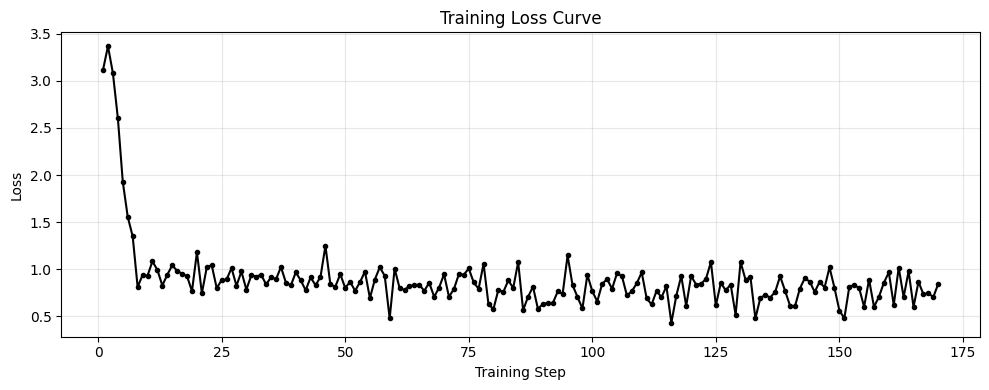

Loss: 3.1167 → 0.8462


In [53]:
# loss
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
steps  = [e["step"] for e in log_history if "loss" in e]
losses = [e["loss"]  for e in log_history if "loss" in e]

plt.figure(figsize=(10, 4))
plt.plot(steps, losses, marker="o", markersize=3, linewidth=1.5, color="black")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Loss: {losses[0]:.4f} → {losses[-1]:.4f}")

## Post-Training Evaluation

Re-running the same MCQ evaluation on the fine-tuned model to measure accuracy improvement.

In [54]:
# === Evaluate MCQ accuracy after fine-tuning ===
print("Evaluating fine-tuned model on MCQ dataset...")
ft_acc, ft_details = eval_mcq_accuracy(
    model,
    tokenizer,
    mcq_df,
    max_new_tokens=EVAL_MAX_NEW_TOKENS,
    return_details=True,
)
ft_details.head()
print(f"Baseline acc: {baseline_acc:.4f}, Fine-tuned acc: {ft_acc:.4f}")

Evaluating fine-tuned model on MCQ dataset...
Processed 20/25 questions...
MCQ accuracy: 96.00% (24/25)
Baseline acc: 0.2400, Fine-tuned acc: 0.9600


Saving the fine-tuned model and tokenizer to disk.

In [55]:
# === Save fine-tuned model (optional) ===
os.makedirs(OUTPUT_DIR, exist_ok=True)
trainer.model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print("Saved fine-tuned model to", OUTPUT_DIR)

Saved fine-tuned model to ./mcq_finetuned_model


## Inference on New Data

Running the fine-tuned model on a held-out test CSV and saving predictions.

Predictions saved to `submission.csv` with `id` and `prediction` columns.

In [56]:
TEST_CSV_PATH = 'test.csv'  # update path to test CSV
test_questions = pd.read_csv(TEST_CSV_PATH)
test_questions
# 1. Make predictions on your finetuned model
# 2. submit to kaggle following the expected format (id, prediction)

,id,question,A,B,C,D,E
0,test_00000,Peanut wants to train a model to accurately cl...,High bias.,Low bias.,High variance.,Low variance.,none of the above
1,test_00001,Consider a binary classification data set with...,Close to zero.,Close to 0.1.,Close to 0.5.,Close to 0.9.,Close to one.
2,test_00002,"Again, consider a binary classification data s...","The precision is 0.1, and the recall is 0.9.","The precision is 0.9, and the recall is 0.1.","The precision is 1.0, and the recall is 0.9.","The precision is 0.9, and the recall is 1.0.","The precision is 0.1, and the recall is 1.0."
3,test_00003,Assume we are given X ∈ Rn×d and y ∈ Rn for n ...,"y′ = [ y; 0d ], X′ = [ X; √λ Id ]","y′ = [ y; 1d ], X′ = [ X; √λ Id ]","y′ = [ y; 0d ], X′ = [ X; λ Id ]","y′ = [ y; 1d ], X′ = [ X; λ Id ]",none of the above
4,test_00004,Which of the following statements are TRUE reg...,“Every entry of a matrix is non-negative” is a...,The singular values of a positive semi-definit...,"If a matrix A is positive semi-definite, then ...",The covariance matrix of any distribution is p...,If the Jacobian of a function is positive semi...
...,...,...,...,...,...,...,...
164,test_00164,Complete the thought in the most sensible way:...,get cold,arousal,sexual excitement,being happy,being hot
165,test_00165,"From everyday intuition, which of these surrou...",matter,muscle,flesh,skin and,cartilage
166,test_00166,"From everyday intuition, Plenty of love, candy...",own home,basket,grandmother's house,apartment complex,trailer park
167,test_00167,Complete the thought in the most sensible way:...,car,shirt pocket,bag,drawer,street


In [57]:
# Run inference on test set
model.eval()
predictions = []

for idx in range(len(test_questions)):
    row = test_questions.iloc[idx]
    user_content = build_mcq_prompt(row)

    messages = [{"role": "user", "content": user_content}]
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=EVAL_MAX_NEW_TOKENS,
            do_sample=False,
        )

    gen_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    decoded = tokenizer.decode(gen_tokens, skip_special_tokens=True)
    pred = parse_choice_from_boxed(decoded)

    # parse fails, replace with C
    if pred is None:
        print(f"  [WARNING] Could not parse row {idx}: '{decoded}'")
        pred = "C"

    predictions.append(pred)

    if (idx + 1) % 20 == 0:
        print(f"  Processed {idx + 1}/{len(test_questions)}...")

# submission CSV
submission = pd.DataFrame({
    "id": test_questions["id"],
    "prediction": predictions,
})
submission.to_csv("submission.csv", index=False)
print(f"Saved {len(submission)} predictions to submission.csv")
print(submission["prediction"].value_counts())
submission.head(10)

  Processed 20/169...
  Processed 40/169...
  [WARNING] Could not parse row 53: '\boxed{ABC}'
  [WARNING] Could not parse row 57: '\boxed{ABC}'
  Processed 60/169...
  Processed 80/169...
  Processed 100/169...
  Processed 120/169...
  Processed 140/169...
  Processed 160/169...

saved submission.csv with 169 rows
prediction
A    53
C    42
B    39
E    18
D    17
Name: count, dtype: int64


,id,prediction
0,test_00000,A
1,test_00001,C
2,test_00002,D
3,test_00003,A
4,test_00004,B
5,test_00005,B
6,test_00006,A
7,test_00007,C
8,test_00008,A
9,test_00009,A


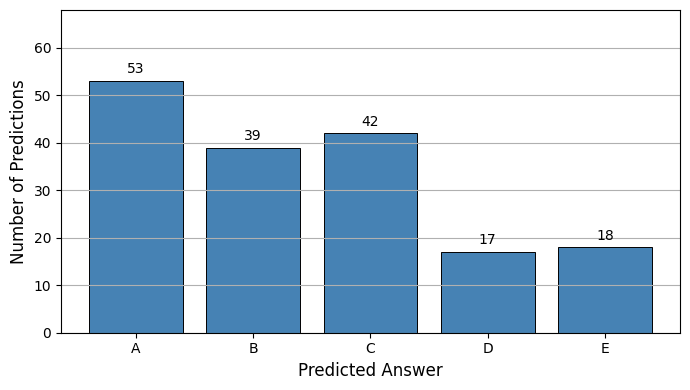

prediction
A    53
B    39
C    42
D    17
E    18

Total predictions: 169


In [58]:
import matplotlib.pyplot as plt
import pandas as pd

submission = pd.read_csv("submission.csv")

counts = submission["prediction"].value_counts().reindex(["A", "B", "C", "D", "E"], fill_value=0)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index, counts.values, color="steelblue", edgecolor="black", linewidth=0.7)

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,str(count), ha="center", va="bottom")

ax.set_xlabel("Predicted Answer", fontsize=12)
ax.set_ylabel("Number of Predictions", fontsize=12)
ax.set_ylim(0, counts.max() + 15)
ax.grid(axis="y")
plt.tight_layout()
plt.show()

print(counts.to_string())
print(f"\nTotal predictions: {len(submission)}")